This is for AI Session # 39 Randomforest_DEcisionTree
Data Set  C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/lab6_data.csv

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree 

In [2]:
# Loading the dataset
df = pd.read_csv('C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/lab6_data.csv')

In [3]:
print(df.head())

   Age  Sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  


In [4]:
print("Total nulls" ,df.isnull().sum())

Total nulls Age         0
Sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [5]:
# Separate input and output data
X = df.drop(columns=['target'])#here X contains all columns except target

In [6]:
y = df['target'] > 0  
# Converted to boolean: True for heart disease, False otherwise

In [7]:
print(X)
print(y)

     Age  Sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1        2  3.0   3.0  
2        2  2.0

In [8]:
# Impute missing values in the input data
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

In [9]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, train_size=0.8)

In [10]:
# Initialize the DecisionTreeClassifier
tree_model = DecisionTreeClassifier()#here the default one is gini index used to split the dataset

In [11]:
# Train the model on the training set
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
# Predict using the validation set
y_pred_tree = tree_model.predict(X_test)

In [13]:
# Calculate the accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree * 100:.2f}%")

Decision Tree Accuracy: 67.21%


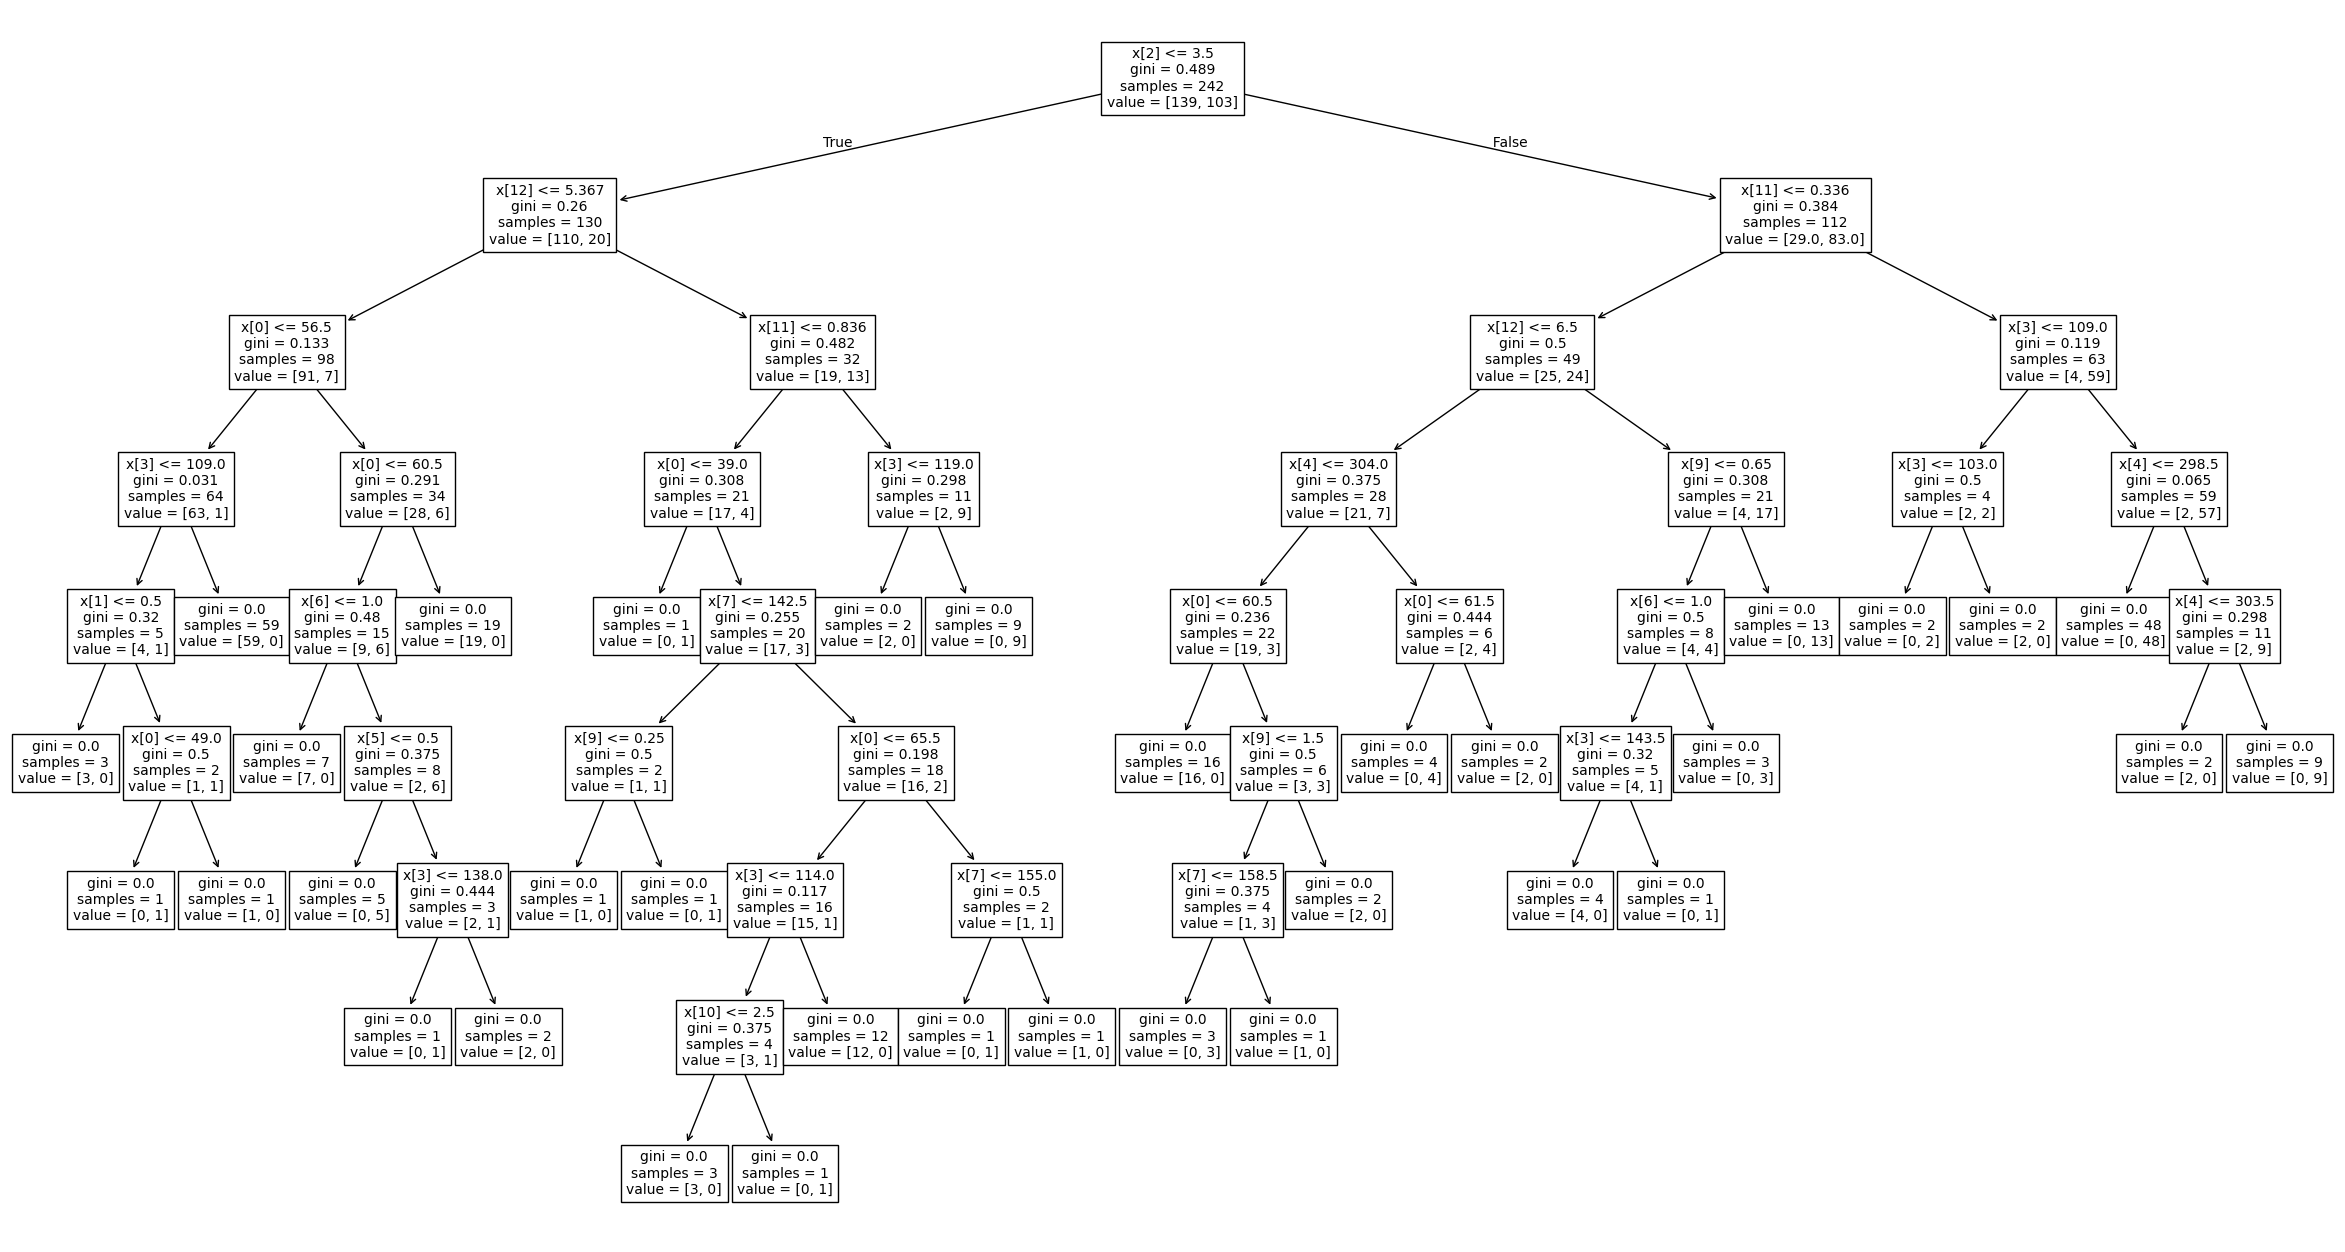

In [14]:
# Plot the decision tree
fig, ax = plt.subplots(figsize=(30, 16))
tree.plot_tree(tree_model, fontsize=10)
plt.show()

In [ ]:
# Initialize the RandomForestClassifier with a max depth of n
forest_model = RandomForestClassifier()#here 100 DT

In [16]:
# Train the model on the training set
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# Predict using the validation set
y_pred_rf = forest_model.predict(X_test)

In [18]:
# Calculate the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 73.77%


"""

# Investigate the most important features
feature_importances = tree_model.feature_importances_
print(feature_importances)
most_important_feature = df.columns[np.argmax(feature_importances)]
print(f"The most important feature according to the decision tree is: {most_important_feature}")




Random forest :
-----------------

Its an ensemble of decsion trees trained on random subsets of data and features,the predictions are combined 
(by voting)to produce a more accurate and stable robust model.

Meaning of ensemble?
--------------------

An ensemble is a combination of multiple models that work together to produce a final and better prediction

simply combining many simple models to reduce the error.


Types of ensemble methods:
---------------------

1.Bagging:
----------

Train many models on random subsets of data
EAch model learns sllightly diff patterns
Combine predicitons by voting in classification 

Ex:Random Forest

2.Boosting:
-----------
Train the models sequentially
EAch new model focuses on errors made by previous ones
Combine all weak models into one strong 

EX:
---
Gradient Boosting
Ada boost

Here finally the new model correct the previous one mistakes.
##############################################################################3

In randomforest example we taken max_depth and num of estimators these we called as hyperparameters

Parameters:
-----------

they are learned from the data during trainng

Hyperparameters:
----------------

we chooseen manually here

Hyperparameret tuning:
---------------------

Searching the best combination hyperparameters


why we need tune?
-----------------

may be overfit
underfit

Overfitting:
-------------

The model learns traing data perfectly but fails on new data

performs good for trainig data but test data not good accuracy

Underfitting:
------------
here the model is very basic that means it cannot capture structure of the data or any patterns from data.

PErforms poorly on trainng data and test data also






"""

In [19]:
# Comparing the accuracies over multiple trials
# why this step?
#Each tree sees a diff random subset of data and features, so each tree learns slightly diff patterns.

"""
tree_accuracies = []
forest_accuracies = []
N = 500
for _ in range(N):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, train_size=0.8)

    # Train and test the decision tree
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)
    tree_accuracies.append(accuracy_score(y_test, y_pred_tree))

    # Train and test the random forest
    forest_model.fit(X_train, y_train)
    y_pred_rf = forest_model.predict(X_test)
    forest_accuracies.append(accuracy_score(y_test, y_pred_rf))

print(tree_accuracies)
print(forest_accuracies)
# Calculate mean and standard deviation
mean_tree_acc = np.mean(tree_accuracies)
std_tree_acc = np.std(tree_accuracies)
mean_forest_acc = np.mean(forest_accuracies)
std_forest_acc = np.std(forest_accuracies)



print(f"Decision Tree - Mean Accuracy: {mean_tree_acc:.2f}, Std Dev: {std_tree_acc:.2f}")
print(f"Random Forest - Mean Accuracy: {mean_forest_acc:.2f}, Std Dev: {std_forest_acc:.2f}")




#Findings 
#print("The Random Forest has a higher mean accuracy compared to the Decision Tree. This is because Random Forests reduce the risk of overfitting by averaging the results of multiple decision trees.")


# Plot histograms of accuracy of each model
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].hist(tree_accuracies, bins=20, color='blue', alpha=0.7)
ax[0].set_title('Decision Tree Accuracy Distribution')
ax[0].set_xlabel('Accuracy')
ax[0].set_ylabel('Frequency')

ax[1].hist(forest_accuracies, bins=20, color='green', alpha=0.7)
ax[1].set_title('Random Forest Accuracy Distribution')
ax[1].set_xlabel('Accuracy')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

"""

AI Session #40 Randomforest example with Hyper Parameter 04/22/2026

In [20]:
# Initialize the RandomForestClassifier with a max depth of n
forest_model = RandomForestClassifier(n_estimators=10,max_depth=4)#here 100 DT

In [21]:
# Train the model on the training set
forest_model.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Predict using the validation set
y_pred_rf = forest_model.predict(X_test)

In [23]:
# Calculate the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 73.77%


In [24]:
tree_accuracies = []
forest_accuracies = []
N = 500
for _ in range(N):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, train_size=0.8)

    # Train and test the decision tree
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)
    tree_accuracies.append(accuracy_score(y_test, y_pred_tree))

    # Train and test the random forest
    forest_model.fit(X_train, y_train)
    y_pred_rf = forest_model.predict(X_test)
    forest_accuracies.append(accuracy_score(y_test, y_pred_rf))

print(tree_accuracies)
print(forest_accuracies)
# Calculate mean and standard deviation
mean_tree_acc = np.mean(tree_accuracies)
std_tree_acc = np.std(tree_accuracies)
mean_forest_acc = np.mean(forest_accuracies)
std_forest_acc = np.std(forest_accuracies)

print(f"Decision Tree - Mean Accuracy: {mean_tree_acc:.2f}, Std Dev: {std_tree_acc:.2f}")
print(f"Random Forest - Mean Accuracy: {mean_forest_acc:.2f}, Std Dev: {std_forest_acc:.2f}")


[0.7704918032786885, 0.7540983606557377, 0.6557377049180327, 0.7704918032786885, 0.6885245901639344, 0.6557377049180327, 0.7213114754098361, 0.7377049180327869, 0.7377049180327869, 0.6721311475409836, 0.6885245901639344, 0.7377049180327869, 0.7377049180327869, 0.7049180327868853, 0.6721311475409836, 0.7377049180327869, 0.7540983606557377, 0.7868852459016393, 0.7049180327868853, 0.7049180327868853, 0.7377049180327869, 0.7049180327868853, 0.7540983606557377, 0.7540983606557377, 0.7540983606557377, 0.7049180327868853, 0.6885245901639344, 0.7868852459016393, 0.7049180327868853, 0.6229508196721312, 0.6721311475409836, 0.6721311475409836, 0.7377049180327869, 0.6885245901639344, 0.7213114754098361, 0.7213114754098361, 0.7704918032786885, 0.7540983606557377, 0.8360655737704918, 0.7377049180327869, 0.7540983606557377, 0.6885245901639344, 0.8032786885245902, 0.6229508196721312, 0.7540983606557377, 0.7704918032786885, 0.6885245901639344, 0.7377049180327869, 0.7213114754098361, 0.6557377049180327,

In [25]:
# Initialize the RandomForestClassifier with a max depth of n
forest_model = RandomForestClassifier(n_estimators=100,max_depth=4)#here 100 DT

In [26]:
# Train the model on the training set
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# Predict using the validation set
y_pred_rf = forest_model.predict(X_test)

In [28]:
# Calculate the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 83.61%


In [29]:
tree_accuracies = []
forest_accuracies = []
N = 500
for _ in range(N):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, train_size=0.8)

    # Train and test the decision tree
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)
    tree_accuracies.append(accuracy_score(y_test, y_pred_tree))

    # Train and test the random forest
    forest_model.fit(X_train, y_train)
    y_pred_rf = forest_model.predict(X_test)
    forest_accuracies.append(accuracy_score(y_test, y_pred_rf))

print(tree_accuracies)
print(forest_accuracies)
# Calculate mean and standard deviation
mean_tree_acc = np.mean(tree_accuracies)
std_tree_acc = np.std(tree_accuracies)
mean_forest_acc = np.mean(forest_accuracies)
std_forest_acc = np.std(forest_accuracies)

print(f"Decision Tree - Mean Accuracy: {mean_tree_acc:.2f}, Std Dev: {std_tree_acc:.2f}")
print(f"Random Forest - Mean Accuracy: {mean_forest_acc:.2f}, Std Dev: {std_forest_acc:.2f}")


[0.7377049180327869, 0.639344262295082, 0.7213114754098361, 0.8032786885245902, 0.7213114754098361, 0.7540983606557377, 0.7704918032786885, 0.7049180327868853, 0.7868852459016393, 0.639344262295082, 0.7540983606557377, 0.7377049180327869, 0.7540983606557377, 0.6721311475409836, 0.7049180327868853, 0.639344262295082, 0.6885245901639344, 0.6721311475409836, 0.7049180327868853, 0.7704918032786885, 0.6721311475409836, 0.7868852459016393, 0.7213114754098361, 0.8360655737704918, 0.7049180327868853, 0.7049180327868853, 0.7704918032786885, 0.7704918032786885, 0.6557377049180327, 0.7213114754098361, 0.7868852459016393, 0.7704918032786885, 0.7213114754098361, 0.7049180327868853, 0.7868852459016393, 0.7377049180327869, 0.7540983606557377, 0.6229508196721312, 0.7049180327868853, 0.7377049180327869, 0.6721311475409836, 0.7049180327868853, 0.7868852459016393, 0.819672131147541, 0.6885245901639344, 0.6229508196721312, 0.7213114754098361, 0.6721311475409836, 0.7868852459016393, 0.8360655737704918, 0.7